In [ ]:
pip install langchain>=0.3.0

In [ ]:
pip show langchain

# 핵심 패키지들
pip install langchain>=0.3.0 langchain-openai langchain-community langchain-text-splitters

# 추가 유용한 패키지들
pip install faiss-cpu tiktoken python-dotenv

# Local Ollama
pip install langchain_ollama

In [ ]:
pip install langchain_ollama

1. 기본 LLM 체인 (Prompt + LLM) =================================================================

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Model
LLM_MODEL = "gemma3:1b"
llm = ChatOllama(
        model = LLM_MODEL,
        temperature=0.1,
        base_url="http://localhost:11434",
        top_k=3
    )

# Prompt
#prompt = ChatPromptTemplate.from_template("You are an expert in astronomy. Answer the question. <Question>: {input}")
prompt = ChatPromptTemplate.from_template("너는 훌륭한 우주인이야. 질문에 답해줘. <Question>: {input}")
#prompt

# 문자열 출력파서
output_parser = StrOutputParser()

# Connect chain (LCEL)
chain = prompt | llm | output_parser

# Call chain
chain.invoke({"input": "지구의 자전주기는?"})

2. 멀티 체인(Multi-Chain)  =================================================================

In [ ]:
prompt1 = ChatPromptTemplate.from_template("translates {korean_word} to English.")
prompt2 = ChatPromptTemplate.from_template("explain {english_word} using oxford dictionary to me in Korean.")

# Connect chain
chain1 = prompt1 | llm | output_parser

# Call chain - JSON format
chain1.invoke({"korean_word": "미래"})

# Connect chain (LCEL)
chain2 = (
            {"english_word": chain1}
            | prompt2
            | llm
            | output_parser
)

# Call chain
chain2.invoke({"korean_word": "미래"})

3. Prompt =================================================================

In [ ]:
#--------------------------------
# LLM
#--------------------------------
from langchain_ollama import ChatOllama

# Model
LLM_MODEL = "gemma3:1b"
llm = ChatOllama(
        model = LLM_MODEL,
        temperature=0.1,
        base_url="http://localhost:11434",
        top_k=3
    )

#--------------------------------
# ChatPromptTemplate
#--------------------------------
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Case1: 2-Tuple Type
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "이 시스템은 천문학의 질문에 답변할 수 있습니다."),
    ("user", "{user_input}"),
])

# check message type
#messages = chat_prompt.format_messages(user_input="태양계에서 가장 큰 행성은 무엇인가요?")
#messages

# call llm
#chain = chat_prompt | llm | StrOutputParser()
#chain.invoke({"user_input": "태양계에서 가장 큰 행성은 무엇인가요?"})

# Case2: MessagePromptTemplate 
from langchain_core.prompts import SystemMessagePromptTemplate,  HumanMessagePromptTemplate

chat_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template("이 시스템은 천문학의 질문에 답변할 수 있습니다."),
    HumanMessagePromptTemplate.from_template("{user_input}"),
])

# check message type
#messages = chat_prompt.format_messages(user_input="태양계에서 가장 큰 행성은 무엇인가요?")
#messages

# call llm
chain = chat_prompt | llm | StrOutputParser()
chain.invoke({"user_input": "태양계에서 가장 큰 행성은 무엇인가요?"})

In [ ]:
pip install langchain_chroma

In [ ]:
#--------------------------------
# LLM
#--------------------------------
from langchain_ollama import ChatOllama

# Model
LLM_MODEL = "gemma3:1b"
llm = ChatOllama(
        model = LLM_MODEL,
        temperature=0.1,
        base_url="http://localhost:11434",
        top_k=3
    )

#--------------------------------
# Embedding Model
#--------------------------------
# 1안)
from langchain_community.embeddings import SentenceTransformerEmbeddings

embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
embeddings = SentenceTransformerEmbeddings(model_name=embedding_model, model_kwargs={"local_files_only":True})

# 2안) Ollama에서 locally run 시킨경우
#from langchain_ollama import OllamaEmbeddings
#embeddings = OllamaEmbeddings(model=embedding_model, validate_model_on_init=True)


#--------------------------------
# Few-shot Prompt
#--------------------------------
from langchain_core.prompts import PromptTemplate

# Few-shot exaplme formatter
example_prompt = PromptTemplate.from_template("질문:{question}\n{answer}")

# Example
examples = [
    {
        "question": "지구의 대기 중 가장 많은 비율을 차지하는 기체는 무엇인가요?",
        "answer": "지구 대기의 약 78%를 차지하는 질소입니다."
    },
    {
        "question": "광합성에 필요한 주요 요소들은 무엇인가요?",
        "answer": "광합성에 필요한 주요 요소는 빛, 이산화탄소, 물입니다."
    },
    {
        "question": "피타고라스 정리를 설명해주세요.",
        "answer": "피타고라스 정리는 직각삼각형에서 빗변의 제곱이 다른 두 변의 제곱의 합과 같다는 것입니다."
    },
    {
        "question": "지구의 자전 주기는 얼마인가요?",
        "answer": "지구의 자전 주기는 약 24시간(정확히는 23시간 56분 4초)입니다."
    },
    {
        "question": "DNA의 기본 구조를 간단히 설명해주세요.",
        "answer": "DNA는 두 개의 폴리뉴클레오티드 사슬이 이중 나선 구조를 이루고 있습니다."
    },
    {
        "question": "원주율(π)의 정의는 무엇인가요?",
        "answer": "원주율(π)은 원의 지름에 대한 원의 둘레의 비율입니다."
    },
]

# Create FewShotPromptTemplate
from langchain_core.prompts import FewShotPromptTemplate
prompt = FewShotPromptTemplate(
    examples = examples,               # 사용할 예제들
    example_prompt = example_prompt,   # 예제 포맷팅에 사용할 템플릿
    suffix = "질문: {input}",          # 예제 뒤에 추가될 접미사
    input_variables = ["input"],
)

# Check prompt
#print(prompt.invoke({"input": "화성의 표면이 붉은 이유는 무엇인가요?"}).to_string())

#-----------------------------------------------------------------

examples = [
    {"input": "지구의 대기 중 가장 많은 비율을 차지하는 기체는 무엇인가요?", "output": "질소입니다."},
    {"input": "광합성에 필요한 주요 요소들은 무엇인가요?", "output": "빛, 이산화탄소, 물입니다."},
    {"input": "피타고라스 정리를 설명해주세요.", "output": "직각삼각형에서 빗변의 제곱은 다른 두 변의 제곱의 합과 같습니다."},
    {"input": "DNA의 기본 구조를 간단히 설명해주세요.", "output": "DNA는 이중 나선 구조를 가진 핵산입니다."},
    {"input": "원주율(π)의 정의는 무엇인가요?", "output": "원의 둘레와 지름의 비율입니다."},
]

# 벡터 저장소 생성
from langchain_chroma import Chroma
from langchain_core.example_selectors import SemanticSimilarityExampleSelector

to_vectorize = [" ".join(example.values()) for example in examples]
vectorstore = Chroma.from_texts(to_vectorize, embeddings, metadatas=examples)
#vectorstore

# 예제 선택기 생성
example_selector = SemanticSimilarityExampleSelector(
    vectorstore=vectorstore,
    k=2
)

# 새로운 질문에 대해 가장 유사한 예제를 선택합니다.
#question = "화성의 표면이 붉은 이유는 무엇인가요?"
#selected_examples = example_selector.select_examples({"question": question})
#print(f"입력과 가장 유사한 예제: {question}")
#for example in selected_examples:
#    print("\n")
#    for k, v in example.items():
#        print(f"{k}: {v}")

# Few-shot 프롬프트 템플릿 생성
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.prompts import FewShotChatMessagePromptTemplate

few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_selector = example_selector,
    example_prompt = ChatPromptTemplate.from_messages(
        [("human", "{input}"), ("ai", "{output}")]
    ),
)

# 최종 프롬프트 템플릿 생성
final_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "당신은 과학과 수학에 대해 잘 아는 교육자입니다."),
        few_shot_prompt,
        ("human", "{input}"),
    ]
)

# 모델과 체인 생성
chain = final_prompt | llm

# 모델에 질문하기
#result = chain.invoke("태양계에서 가장 큰 행성은 무엇인가요?")
#print(result.content)

#question = "태양계에서 가장 큰 행성은 무엇인가요?"
question = "SpaceX의 화성 이주 계획에 대해서 설명해줘"
for chunk in chain.stream(question):
    print(chunk.text, end="", flush=True)

4. Output Parser

PandasDataFrameOutputParser

In [ ]:
pip install pandas

In [ ]:
pip install -U langchain

In [ ]:
import pprint
from typing import Any, Dict

import pandas as pd
#from langchain_core.output_parsers import PandasDataFrameOutputParser
from langchain_core.prompts import PromptTemplate

#----------------------
# LLM 초기화
#----------------------
from langchain_ollama import ChatOllama
# Model
LLM_MODEL = "gemma3:1b"
llm = ChatOllama(
        model = LLM_MODEL,
        temperature=0.1,
        base_url="http://localhost:11434",
        top_k=3
    )

# 파서 출력을 사전 형식으로 변환하고 출력 형식을 지정
def format_parser_output(parser_output: Dict[str, Any]) -> None:
    # 파서 출력의 키들을 순회합니다.
    for key in parser_output.keys():
        # 각 키의 값을 딕셔너리로 변환합니다.
        parser_output[key] = parser_output[key].to_dict()
    # 예쁘게 출력합니다.
    return pprint.PrettyPrinter(width=4, compact=True).pprint(parser_output)

# csv 데이터를 읽어온 뒤 DataFrame 을 로드하여 df 변수에 할당
df = pd.read_csv("./data/titanic.csv")
# csv 파일의 처음 5개의 row만 조회
#df.head()

# column name 조회
columns_list = df.columns.tolist()
print(columns_list)

# DataFrame의 정보 조회
df.info()

# 특정 컬럼의 내용 조회
print('\n')
for idx, value in enumerate(df['Age'].values):
    print(idx, ' ', value)

5. Cache

In [ ]:
#--------------------------------
# LLM
#--------------------------------
from langchain_ollama import ChatOllama

# Model
LLM_MODEL = "gemma3:1b"
llm = ChatOllama(
        model = LLM_MODEL,
        temperature=0.1,
        base_url="http://localhost:11434",
        top_k=3
    )

from langchain_core.prompts import PromptTemplate

# 프롬프트를 생성합니다.
prompt = PromptTemplate.from_template("{country} 에 대해서 200자 내외로 요약해줘")

# 체인을 생성합니다.
chain = prompt | llm

In [ ]:
%%time 
response = chain.invoke({"country": "한국"})
print(response.content)
#### 캐쉬 미사용

5-1. InMemoryCache

In [ ]:
%%time

###### 캐쉬 사용 설정
from langchain_core.caches import InMemoryCache
from langchain_core.globals import set_llm_cache

# 인메모리 캐시 설정
# maxsize 매개변수를 사용하여 최대 캐시 크기를 지정할 수 있습니다 (기본값: 무제한)
#set_llm_cache(InMemoryCache())
set_llm_cache(InMemoryCache(maxsize=100))

# 체인을 실행합니다.
response = chain.invoke({"country": "한국"})
print(response.content) 

In [ ]:
%%time

###### 캐쉬된 내용 조회
# 체인을 실행합니다.
response = chain.invoke({"country": "한국"})
print(response.content)

5-2. SQLite Cache

In [ ]:
from langchain_community.cache import SQLiteCache
from langchain_core.globals import set_llm_cache
import os

# 캐시 디렉토리를 생성합니다.
if not os.path.exists("cache"):
    os.makedirs("cache")

# SQLiteCache를 사용합니다.
set_llm_cache(SQLiteCache(database_path="cache/llm_cache.db"))

In [ ]:
%%time 
# 체인을 실행합니다.
response = chain.invoke({"country": "한국"})
print(response.content)

6. Model Serialize

6-1. 직렬화

In [ ]:
import os
from langchain_core.prompts import PromptTemplate

#--------------------------------
# LLM
#--------------------------------
from langchain_ollama import ChatOllama

# Model
LLM_MODEL = "gemma3:1b"
llm = ChatOllama(
        model = LLM_MODEL,
        temperature=0.1,
        base_url="http://localhost:11434",
        top_k=3
    )

# 프롬프트 템플릿을 사용하여 질문을 생성합니다.
prompt = PromptTemplate.from_template("{fruit}의 색상이 무엇입니까?")

# (1) LLM객체의 직렬화 가능여부 확인
print(f"ChatOllama LLM: {ChatOllama.is_lc_serializable()}")

# (2) 체인 직렬화 가능여부 확인
# 체인을 생성합니다.
chain = prompt | llm

# 직렬화가 가능한지 체크합니다.
chain_isSerializable = chain.is_lc_serializable()
print(f"Chain: {chain_isSerializable}")

print("\n#---------------------------------\n")

#[chain 직렬화]
#dumps: 객체를 JSON 문자열로 직렬화
#dumpd: 객체를 딕셔너리로 직렬화

from langchain_core.load import dumpd, dumps

# 객체 직렬화
dumpd_chain = dumpd(chain)
print("1) dumpd_chain -------------------------------")
print(dumpd_chain)

# 직렬화된 체인의 타입을 확인합니다.
print("")
print(type(dumpd_chain))
print("")

# 체인 직렬화
# dumps 함수를 사용하여 직렬화된 체인을 확인합니다.
dumps_chain = dumps(chain)
print("2) dumps_chain -------------------------------")
print(dumps_chain)

# 직렬화된 체인의 타입을 확인합니다.
print("")
print(type(dumps_chain))
print("")

6-2. pickle을 이용한 Python 객체의 바이너리 직렬화

In [ ]:
#-------------------------------------
# Pickle 파일로 저장
#-------------------------------------
import pickle

#pickle.dump(): 객체를 파일에 저장
#pickle.load(): 파일에서 객체 로드

# fuit_chain.pkl 파일로 직렬화된 체인을 저장합니다.
with open("fruit_chain.pkl", "wb") as f:
    pickle.dump(dumps_chain, f)

# pickle 파일을 로드합니다.
with open("fruit_chain.pkl", "rb") as f:
    loaded_chain = pickle.load(f)
    #print(loaded_chain)


# 체인을 로드합니다.
from langchain_core.load import load, loads
#chain_from_file = loads(loaded_chain)   <- beta 미구현

# 체인을 실행합니다.
print(chain_from_file.invoke({"fruit": "사과"}))

    

In [ ]:
6-3. json 파일을 이용한 직렬화

In [ ]:
import json

with open("fruit_chain.json", "w") as fp:
    json.dump(dumps_chain, fp)

from langchain_core.load import load, loads

# 체인을 로드합니다.
#chain_from_file = load(loaded_chain)


# 체인을 실행합니다.
#print(chain_from_file.invoke({"fruit": "사과"}))    


with open("fruit_chain.json", "r") as fp:
    loaded_from_json_chain = json.load(fp)
    loads_chain = loads(loaded_from_json_chain)

# 불러온 체인이 정상 동작하는지 확인합니다.
loads_chain.invoke({"fruit": "사과"})    

7. Multimodal


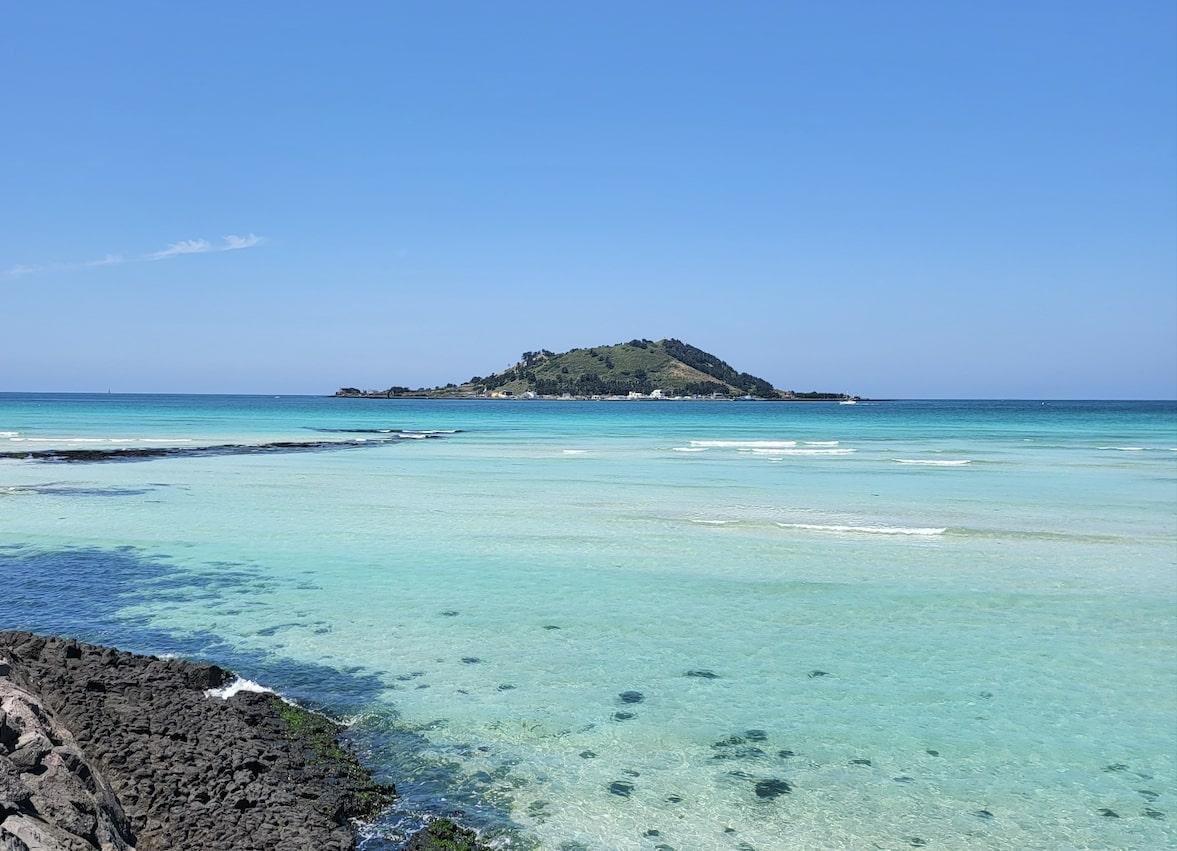

In [8]:
import base64
from io import BytesIO

from IPython.display import HTML, display
from PIL import Image
from langchain_core.messages import HumanMessage

def convert_to_base64(pil_image):
    """
    PIL 이미지를 Base64로 인코딩된 문자열로 변환합니다.

    :param pil_image: PIL 이미지
    :return: 크기 조정된 Base64 문자열
    """

    buffered = BytesIO()
    pil_image.save(buffered, format="JPEG")  # 필요한 경우 형식을 변경할 수 있습니다.
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 문자열을 이미지로 표시합니다.

    :param img_base64:  Base64 문자열
    """
    # Base64 문자열을 소스로 사용하여 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))


def prompt_func(data):  # 프롬프트 함수를 정의합니다.
    text = data["text"]  # 데이터에서 텍스트를 가져옵니다.
    image = data["image"]  # 데이터에서 이미지를 가져옵니다.

    image_part = {  # 이미지 부분을 정의합니다.
        "type": "image_url",  # 이미지 URL 타입을 지정합니다.
        "image_url": f"data:image/jpeg;base64,{image}",  # 이미지 URL을 생성합니다.
    }

    content_parts = []  # 콘텐츠 부분을 저장할 리스트를 초기화합니다.

    text_part = {"type": "text", "text": text}  # 텍스트 부분을 정의합니다.

    content_parts.append(image_part)  # 이미지 부분을 콘텐츠 부분에 추가합니다.
    content_parts.append(text_part)  # 텍스트 부분을 콘텐츠 부분에 추가합니다.

    return [HumanMessage(content=content_parts)]  # HumanMessage 객체를 반환합니다.


file_path = "./images/jeju-beach.jpg"
pil_image = Image.open(file_path)

image_b64 = convert_to_base64(pil_image)

plt_img_base64(image_b64)

In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage

# ChatOllama 멀티모달 언어 모델을 불러옵니다.
#--------------------------------
# LLM
#--------------------------------
from langchain_ollama import ChatOllama

# Model
LLM_MODEL = "gemma3:4b"
llm = ChatOllama(
        model = LLM_MODEL,
        temperature=0.1,
        base_url="http://localhost:11434",
        top_k=3
    )

# 프롬프트 함수, 언어 모델, 출력 파서를 연결하여 체인을 생성합니다.
chain = prompt_func | llm | StrOutputParser()

#query_chain = chain.invoke(  # 체인을 호출하여 쿼리를 실행합니다.
    # 텍스트와 이미지를 전달합니다.
#    {"text": "사진에 대해서 설명해줘", "image": image_b64}
#)

#print(query_chain)  # 쿼리 결과를 출력합니다.

for chunk in chain.stream({"text": "이 사진은 제주도 해변의 사진이야. 사진에 대해서 좀더 자세히 설명해줘", "image": image_b64}):
    print(chunk, end="", flush=True)

네, 사진은 아름다운 제주도 해변 풍경을 담고 있네요. 사진에 대한 자세한 설명을 드리겠습니다.

**전반적인 분위기:**

*   **맑고 푸른 하늘:** 사진의 배경은 맑고 푸른 하늘로, 시원하고 깨끗한 느낌을 줍니다.
*   **맑고 투명한 바다:** 바다는 맑고 투명하여, 바닥의 수중 생물이나 해변의 모래까지 잘 드러나 있습니다.
*   **평화로운 분위기:** 전체적으로 평화롭고 한적한 분위기를 자아냅니다.

**주요 요소:**

*   **섬:** 사진의 중심에는 작은 섬이 보입니다. 섬은 울창한 녹지로 뒤덮여 있으며, 섬의 모습이 더욱 아름답게 느껴집니다.
*   **해변:** 해변은 넓게 펼쳐져 있으며, 잔잔한 파도가 일렁이는 모습이 인상적입니다.
*   **모래:** 해변에는 흰색의 모래가 넓게 깔려 있으며, 파도에 의해 흩어져 있습니다.
*   **파도:** 잔잔한 파도가 해변을 따라 흐르는 모습이 평화로운 분위기를 더합니다.
*   **배:** 멀리 배가 정박되어 있는 모습이 보입니다.

**색감:**

*   **푸른색:** 바다와 하늘은 푸른색을 주조로 하여 시원하고 맑은 느낌을 줍니다.
*   **흰색:** 모래는 흰색으로, 햇빛을 반사하여 더욱 깨끗하고 밝은 느낌을 줍니다.
*   **녹색:** 섬의 울창한 녹색은 생동감을 더합니다.

**전반적으로 이 사진은 제주도의 아름다운 해변을 잘 보여주고 있으며, 방문하고 싶은 풍경을 연상시키는 사진입니다.**

혹시 사진에 대해 더 궁금한 점이 있으시면 언제든지 질문해주세요.

In [9]:
pip show langchain

Name: langchain
Version: 1.0.5
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: C:\Users\77100643\anaconda3\Lib\site-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 
Note: you may need to restart the kernel to use updated packages.
